## 1. SetUp

In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="J1rWUvuwvKwOyLI5ooEK")
project = rf.workspace("sanjana-kazi-supti-ymhu2").project("non-seasonal-vegetable-detection-yms0u")
version = project.version(3)
dataset = version.download("yolov12")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 30.9 MB/s eta 0:00:00
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=


Extracting Dataset Version Zip to Non-Seasonal-Vegetable-Detection-3 in yolov12:: 100%|██████████| 9606/9606 [00:00<00:00, 10208.70it/s]


In [2]:
!pip install ultralytics --no-deps
import ultralytics
ultralytics.checks()

Ultralytics 8.4.48 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6842.1/8062.4 GB disk)


In [3]:
!pip install pycocotools tqdm

In [4]:
import os, json, yaml, math, gc, random, shutil, contextlib
from pathlib import Path
from PIL import Image

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
print("Device:", device, "| torch", torch.__version__)

def autocast_ctx():
    return torch.autocast(device_type="cuda", enabled=True) if device=="cuda" else contextlib.nullcontext()

Device: cuda | torch 2.6.0+cu124


In [5]:
WORK          = Path("/kaggle/working/Non-Seasonal-Vegetable-Detection-3")  # output directory (can rename)
SSL_W         = WORK / "ssl_yolo_backbone.pt"

## 2. Multi-crop Augmentation (DINOv2-style: 2 global + 8 local)

In [6]:

class MultiCropDINO(Dataset):
    SUPP=('*.jpg','*.jpeg','*.png','*.JPG','*.JPEG','*.PNG')
    def __init__(self, roots, g_size=224, l_size=96, n_local=8):
        self.files=[p for r in roots for s in self.SUPP for p in Path(r).rglob(s)]
        if not self.files: raise RuntimeError("No images found for SSL.")
        self.g1 = transforms.Compose([
            transforms.RandomResizedCrop(g_size, scale=(0.4, 1.0), interpolation=transforms.InterpolationMode.BICUBIC),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(0.4,0.4,0.4,0.1),
            transforms.RandomGrayscale(0.2),
            transforms.GaussianBlur(1, 0.1),
            transforms.ToTensor()
        ])
        self.g2 = transforms.Compose([
            transforms.RandomResizedCrop(g_size, scale=(0.4, 1.0), interpolation=transforms.InterpolationMode.BICUBIC),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(0.4,0.4,0.4,0.1),
            transforms.RandomGrayscale(0.2),
            transforms.ToTensor()
        ])
        self.local = transforms.Compose([
            transforms.RandomResizedCrop(l_size, scale=(0.05, 0.4), interpolation=transforms.InterpolationMode.BICUBIC),
            transforms.Resize(g_size, interpolation=transforms.InterpolationMode.BICUBIC),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(0.4,0.4,0.4,0.1),
            transforms.RandomGrayscale(0.2),
            transforms.ToTensor()
        ])
        self.n_local = n_local
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        crops=[self.g1(img), self.g2(img)]
        crops.extend([self.local(img) for _ in range(self.n_local)])
        return crops

## 3. Build YOLO V12s model type backbone dino-v2 style

In [7]:
detector = YOLO("yolo12s.pt")   # requires Ultralytics with YOLOv10 assets
model = detector.model

student_bb = model.model[0].to(device)
teacher_bb = YOLO("yolo12s.pt").model.model[0].to(device)
teacher_bb.load_state_dict(student_bb.state_dict())
for p in teacher_bb.parameters(): p.requires_grad=False

def _pick_last_feat(out):
    """Return a tensor representing the deepest feature map/vector from backbone output."""
    if isinstance(out, (list, tuple)) and len(out) > 0:
        t = out[-1]
    elif isinstance(out, dict) and len(out) > 0:
        t = list(out.values())[-1]
    else:
        t = out
    if not torch.is_tensor(t):
        # some modules could return nested structures
        if isinstance(t, (list, tuple)) and len(t) > 0 and torch.is_tensor(t[-1]):
            t = t[-1]
        elif isinstance(t, dict) and len(t) > 0 and torch.is_tensor(list(t.values())[-1]):
            t = list(t.values())[-1]
        else:
            raise RuntimeError("Backbone output type not understood.")
    return t

class BackboneEncoder(nn.Module):
    def __init__(self, bb): super().__init__(); self.bb=bb
    def forward(self, x):
        out = self.bb(x)
        t = _pick_last_feat(out)
        # shape adapt: [B,C,H,W] → GAP; [B,C,T] → mean over T; [B,C] → as-is; else flatten
        if t.ndim == 4:
            z = t.mean(dim=(2,3))
        elif t.ndim == 3:
            z = t.mean(dim=2)
        elif t.ndim == 2:
            z = t
        else:
            z = t.view(t.size(0), -1)
        return z

student_enc = BackboneEncoder(student_bb).to(device)
teacher_enc = BackboneEncoder(teacher_bb).to(device)

with torch.no_grad():
    dmy = torch.zeros(1,3,224,224,device=device)
    feat_dim = student_enc(dmy).shape[1]
print("Backbone feature dim:", feat_dim)

Backbone feature dim: 32


## 4. DINO-v2 style projection head and loss function

In [8]:
OUT_DIM = 256

def projector(in_dim, hid=2048, out=OUT_DIM):
    return nn.Sequential(
        nn.Linear(in_dim, hid), nn.GELU(), nn.BatchNorm1d(hid),
        nn.Linear(hid, out)
    )

student_head = projector(feat_dim).to(device)
teacher_head = projector(feat_dim).to(device)
teacher_head.load_state_dict(student_head.state_dict())
for p in teacher_head.parameters(): p.requires_grad=False

class DINOLoss(nn.Module):
    def __init__(self, out_dim, n_global=2,
                 teacher_temp_warm=0.04, teacher_temp=0.07,
                 warmup_frac=0.1, total_epochs=100,
                 center_m=0.9, student_temp=0.1):
        super().__init__()
        self.n_global=n_global
        self.t_warm, self.t_final = teacher_temp_warm, teacher_temp
        self.warmup_frac, self.T = warmup_frac, total_epochs
        self.cm = center_m
        self.student_temp = student_temp
        self.register_buffer("center", torch.zeros(1,out_dim))
    def teacher_T(self, epoch):
        if epoch < self.warmup_frac*self.T:
            a=epoch/(self.warmup_frac*self.T)
            return self.t_warm + (self.t_final-self.t_warm)*a
        return self.t_final
    def forward(self, s_out, t_out, epoch):
        Tt = self.teacher_T(epoch)
        s_logits = [s/self.student_temp for s in s_out]
        t_probs  = [F.softmax((t - self.center)/Tt, dim=-1).detach() for t in t_out]
        loss=0; cnt=0
        for iq, q in enumerate(t_probs):
            for v, s in enumerate(s_logits):
                if v==iq:  # skip same-index global view
                    continue
                loss += -(q * F.log_softmax(s, dim=-1)).sum(1).mean()
                cnt += 1
        loss /= max(cnt,1)
        with torch.no_grad():
            batch_center = torch.cat(t_out, 0).mean(0, keepdim=True)
            self.center = self.center*self.cm + (1-self.cm)*batch_center
        return loss


## 5. DINOv2-style self training loop with hyperparameter and optimizer

In [9]:

EPOCHS     = 50       # increase to 50–100 for stronger transfer
BATCH      = 64
ACCUM      = 1
LR         = 5e-4
WD         = 0.05
EMA0       = 0.996
N_LOCAL    = 8
NUM_WORKERS= 0

if SSL_W.exists():
    print("✓ SSL backbone cache found – skipping DINOv2-style pretrain")
else:
    print("\n DINOv2-style pretraining on YOLOv12s backbone …")
    ds = MultiCropDINO([WORK/"train/images", WORK/"valid/images", WORK/"test/images"],
                       g_size=224, l_size=96, n_local=N_LOCAL)
    dl = DataLoader(ds, batch_size=BATCH, shuffle=True, num_workers=NUM_WORKERS,
                    pin_memory=True, drop_last=True)

    params = list(student_enc.parameters()) + list(student_head.parameters())
    opt = torch.optim.AdamW(params, lr=LR, weight_decay=WD)
    lr_sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    scaler = torch.amp.GradScaler(enabled=(device=="cuda"))
    loss_fn = DINOLoss(OUT_DIM, n_global=2,
                       teacher_temp_warm=0.04, teacher_temp=0.07,
                       warmup_frac=0.1, total_epochs=EPOCHS,
                       center_m=0.9, student_temp=0.1).to(device)

    steps_per_epoch = len(dl)
    total_steps = steps_per_epoch * EPOCHS
    gstep = 0

    student_enc.train(); student_head.train()
    for ep in range(EPOCHS):
        ep_loss=0.0; accum=0
        opt.zero_grad(set_to_none=True)
        for views in tqdm(dl, desc=f"SSL Ep {ep+1}/{EPOCHS}", leave=False):
            views = [v.to(device) for v in views]  # [g1, g2, l1..lN]
            with autocast_ctx():
                s_feats = [student_enc(v) for v in views]
                s_outs  = [student_head(z) for z in s_feats]              # all crops
                with torch.no_grad():
                    t_feats = [teacher_enc(v) for v in views[:2]]         # globals only
                    t_outs  = [teacher_head(z) for z in t_feats]
                loss = loss_fn(s_outs, t_outs, epoch=ep) / ACCUM

            scaler.scale(loss).backward()
            accum += 1
            if accum == ACCUM:
                scaler.unscale_(opt)
                nn.utils.clip_grad_norm_(params, 3.0)
                scaler.step(opt); scaler.update()
                opt.zero_grad(set_to_none=True)
                accum = 0

                # EMA update (cosine momentum) for teacher backbone + head
                m = 1 - (1-EMA0) * (math.cos(math.pi*gstep/total_steps)+1)/2
                with torch.no_grad():
                    for ps, pt in zip(student_bb.parameters(), teacher_bb.parameters()):
                        pt.data.mul_(m).add_(ps.data, alpha=1-m)
                    for ps, pt in zip(student_head.parameters(), teacher_head.parameters()):
                        pt.data.mul_(m).add_(ps.data, alpha=1-m)
                gstep += 1

            ep_loss += loss.item() * ACCUM

        lr_sched.step()
        print(f"SSL Epoch {ep+1:02d}: loss={ep_loss/steps_per_epoch:.4f}")

    SSL_W.parent.mkdir(parents=True, exist_ok=True)
    torch.save(student_bb.state_dict(), SSL_W)
    del ds, dl
    gc.collect()
    print("✓ Saved SSL YOLOv12s backbone →", SSL_W)
    print("✓ DINOv2-style pretraining complete.\n")


 DINOv2-style pretraining on YOLOv12s backbone …


SSL Ep 1/50:   0%|          | 0/74 [00:00<?, ?it/s]

SSL Epoch 01: loss=6.3898


SSL Ep 2/50:   0%|          | 0/74 [00:00<?, ?it/s]

SSL Epoch 02: loss=4.9545


...

SSL Epoch 48: loss=4.4881


SSL Ep 49/50:   0%|          | 0/74 [00:00<?, ?it/s]

SSL Epoch 49: loss=4.4900


SSL Ep 50/50:   0%|          | 0/74 [00:00<?, ?it/s]

SSL Epoch 50: loss=4.4770
✓ Saved SSL YOLOv12s backbone → /kaggle/working/Non-Seasonal-Vegetable-Detection-3/ssl_yolo_backbone.pt
✓ DINOv2-style pretraining complete.



## 6. PCA Visualization of K-Means clustering

In [10]:
!pip install --quiet --upgrade numpy==1.25.2 scipy==1.10.1 scikit-learn==1.3.2 umap-learn==0.20.0
!pip install ultralytics --no-deps

import ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 3.0 MB/s eta 0:00:00
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.7.2 Requires-Python >=3.7,<3.11; 1.7.3 Requires-Python >=3.7,<3.11; 1.8.0 Requires-Python >=3.8,<3.11; 1.8.0rc1 Requires-Python >=3.8,<3.11; 1.8.0rc2 Requires-Python >=3.8,<3.11; 1.8.0rc3 Requires-Python >=3.8,<3.11; 1.8.0rc4 Requires-Python >=3.8,<3.11; 1.8.1 Requires-Python >=3.8,<3.11
ERROR: Could not find a version that satisfies the requirement umap-learn==0.20.0 (from versions: 0.1.0, 0.1.1, 0.1.2, 0.1.3, 0.1.4, 0.1.5, 0.2.0, 0.2.1, 0.2.2, 0.2.3, 0.2.4, 0.2.5, 0.3.0, 0.3.1, 0.3.2, 0.3.4, 0.3.5, 0.3.6, 0.3.7,

E0000 00:00:1778450195.731834      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778450195.778545      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Feature matrix shape: (1000, 32)
UMAP failed: check_array() got an unexpected keyword argument 'ensure_all_finite'


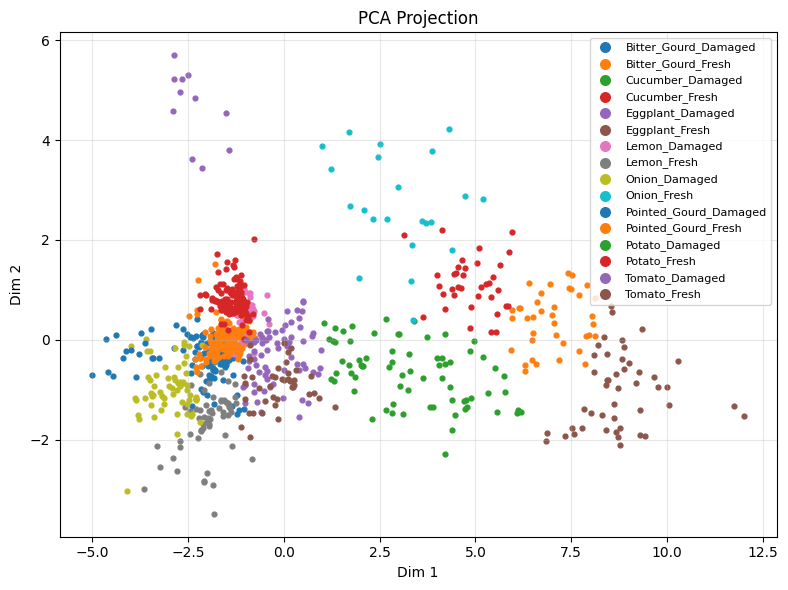

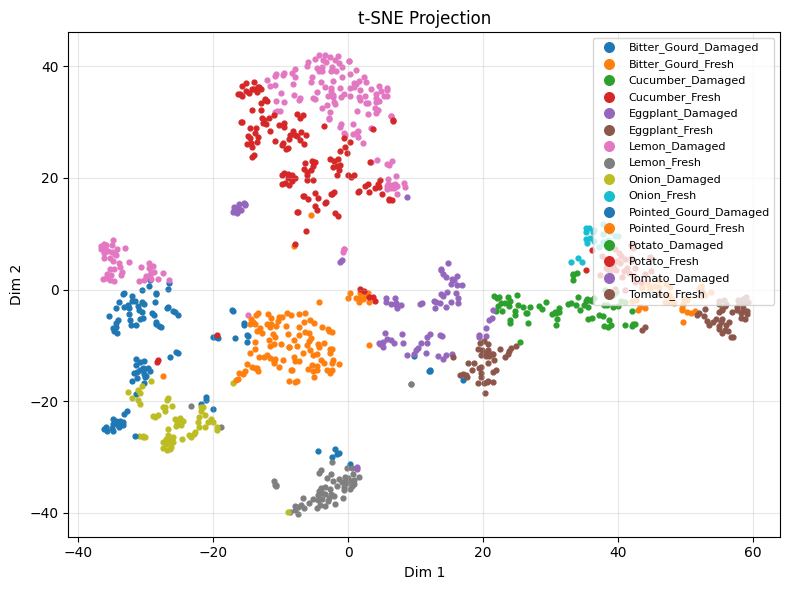

In [11]:
import torch, random, gc
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from torch import nn
from torchvision import transforms
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import yaml

# Try importing UMAP (Python >=3.11 compatible versions only)
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    print("UMAP not installed or incompatible. Skipping UMAP.")
    UMAP_AVAILABLE = False

# ===================================
# Paths
# ===================================
SSL_W = WORK / "ssl_yolo_backbone.pt"
DATA_YAML = WORK / "data.yaml"

# Load class names from data.yaml
if DATA_YAML.exists():
    with open(DATA_YAML, "r") as f:
        data_dict = yaml.safe_load(f)
    class_names = data_dict.get("names", None)  # this will be a list
    if class_names is None:
        class_names = []
    k = len(class_names)
else:
    class_names = []
    k = 5  # fallback

# ===================================
# Load SSL backbone and YOLOv12s
# ===================================
det_pca = YOLO("yolo12s.pt")
det_pca.model.model[0].load_state_dict(torch.load(SSL_W, map_location="cpu"), strict=False)
bb = det_pca.model.model[0].to(device).eval()

class BBEnc(nn.Module):
    def __init__(self, bb): 
        super().__init__()
        self.bb = bb
    def forward(self, x):
        out = self.bb(x)
        t = _pick_last_feat(out)
        if t.ndim == 4:
            z = t.mean(dim=(2,3))
        elif t.ndim == 3:
            z = t.mean(dim=2)
        elif t.ndim == 2:
            z = t
        else:
            z = t.view(t.size(0), -1)
        return z

enc_pca = BBEnc(bb).to(device)
tfm_pca = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor()])

# ===================================
# Sample images
# ===================================
IMG_DIRS = [WORK/"train/images", WORK/"valid/images"]
files = []
for d in IMG_DIRS:
    if d.exists():
        files += list(d.glob("*.*"))
random.shuffle(files)
files = files[:1000] if len(files) > 1000 else files

feats = []
with torch.no_grad():
    for p in files:
        try:
            img = Image.open(p).convert("RGB")
        except:
            continue
        x = tfm_pca(img).unsqueeze(0).to(device)
        z = enc_pca(x)
        feats.append(z.squeeze(0).cpu().numpy())

feats = np.stack(feats, axis=0).astype(np.float32)
print("Feature matrix shape:", feats.shape)

# ===================================
# Dimensionality reduction
# ===================================
xy_pca = PCA(n_components=2, random_state=42).fit_transform(feats)
xy_tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42).fit_transform(feats)

xy_umap = None
if UMAP_AVAILABLE:
    try:
        xy_umap = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(feats)
    except Exception as e:
        print(f"UMAP failed: {e}")
        xy_umap = None

# ===================================
# Clustering
# ===================================
labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(feats)

# ===================================
# Plotting individual figures
# ===================================
methods = [("PCA", xy_pca), ("t-SNE", xy_tsne)]
if xy_umap is not None:
    methods.append(("UMAP", xy_umap))

# Colormap
cmap = plt.colormaps["tab10"]

for title, xy in methods:
    plt.figure(figsize=(8, 6))
    for i in range(k):
        mask = labels == i
        label_name = class_names[i] if class_names else f"C{i}"
        plt.scatter(xy[mask, 0], xy[mask, 1], s=12, label=label_name, color=cmap(i % 10))
    plt.title(f"{title} Projection")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.legend(markerscale=2, fontsize=8)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


Classes: ['Bitter_Gourd_Damaged', 'Bitter_Gourd_Fresh', 'Cucumber_Damaged', 'Cucumber_Fresh', 'Eggplant_Damaged', 'Eggplant_Fresh', 'Lemon_Damaged', 'Lemon_Fresh', 'Onion_Damaged', 'Onion_Fresh', 'Pointed_Gourd_Damaged', 'Pointed_Gourd_Fresh', 'Potato_Damaged', 'Potato_Fresh', 'Tomato_Damaged', 'Tomato_Fresh']
Total sampled images: 1000
Feature matrix shape: (1000, 32)

➤ Running KMeans clustering ...
➤ Running PCA ...
PCA explained variance: 70.15%
➤ Running t-SNE ...
➤ Running UMAP ...
UMAP failed: check_array() got an unexpected keyword argument 'ensure_all_finite'


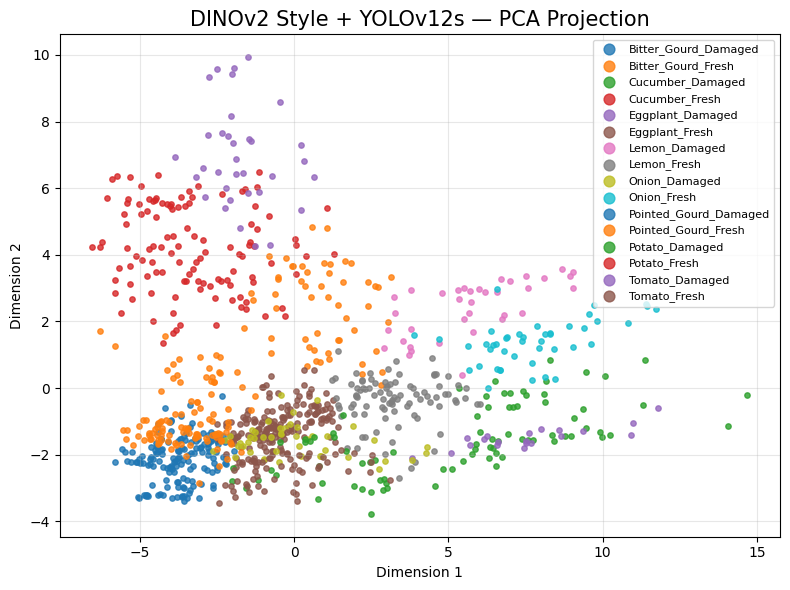

Saved: /kaggle/working/Non-Seasonal-Vegetable-Detection-3/plots/pca_projection.png


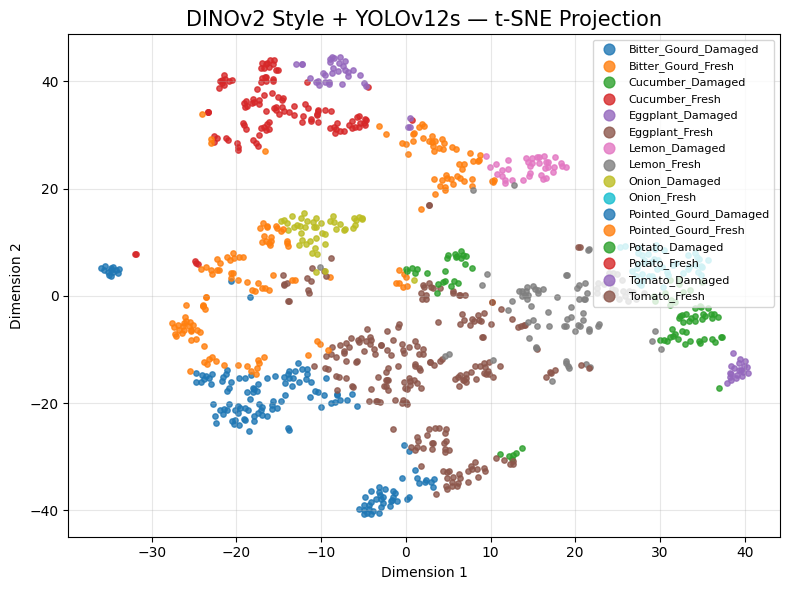

Saved: /kaggle/working/Non-Seasonal-Vegetable-Detection-3/plots/t-sne_projection.png

➤ Running k-NN classification ...
k-NN Accuracy: 0.8900


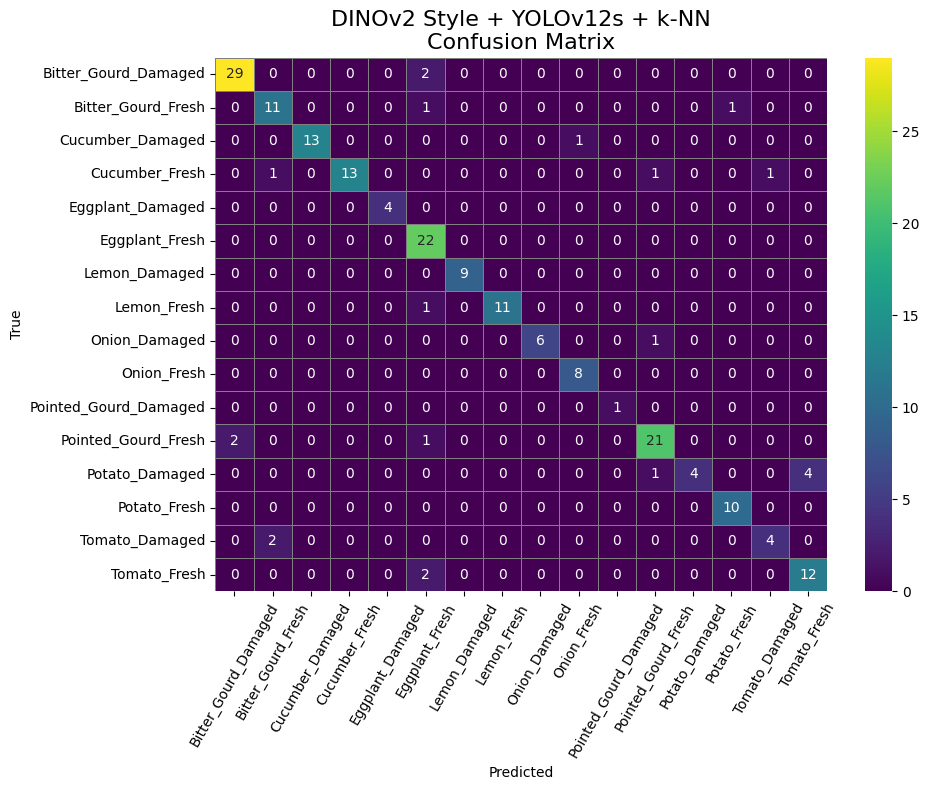

Saved: /kaggle/working/Non-Seasonal-Vegetable-Detection-3/plots/knn_confusion_matrix.png

➤ Plotting t-SNE prediction errors ...


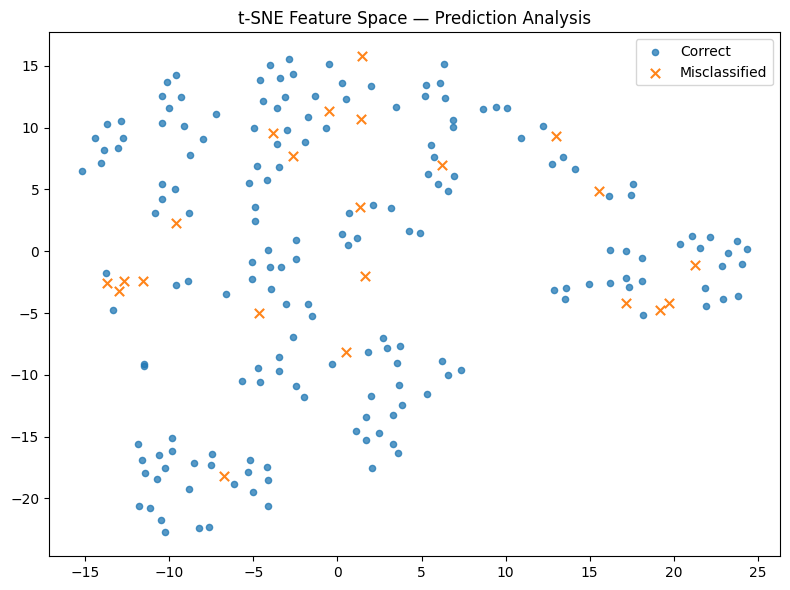

Saved: /kaggle/working/Non-Seasonal-Vegetable-Detection-3/plots/tsne_prediction_analysis.png

✓ ALL VISUALIZATIONS GENERATED SUCCESSFULLY
✓ Saved inside: /kaggle/working/Non-Seasonal-Vegetable-Detection-3/plots


In [12]:
# ============================================================
# DINOv2 STYLE + YOLOv12s FEATURE VISUALIZATION PIPELINE
# ============================================================

import torch
import random
import gc
import yaml
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from torch import nn
from torchvision import transforms

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# ============================================================
# OPTIONAL UMAP
# ============================================================

try:
    import umap

    UMAP_AVAILABLE = True

except ImportError:

    print("UMAP not installed or incompatible.")
    UMAP_AVAILABLE = False

# ============================================================
# PATHS
# ============================================================

SSL_W    = WORK / "ssl_yolo_backbone.pt"
DATA_YAML = WORK / "data.yaml"

PLOTS = WORK / "plots"
PLOTS.mkdir(exist_ok=True)

# ============================================================
# LOAD CLASS NAMES
# ============================================================

if DATA_YAML.exists():

    with open(DATA_YAML, "r") as f:
        data_dict = yaml.safe_load(f)

    class_names = data_dict.get("names", [])

else:

    class_names = []

k = len(class_names) if len(class_names) > 0 else 5

print("Classes:", class_names)

# ============================================================
# LOAD YOLOv12s + SSL BACKBONE
# ============================================================

det_pca = YOLO("yolo12s.pt")

det_pca.model.model[0].load_state_dict(
    torch.load(SSL_W, map_location="cpu"),
    strict=False
)

bb = det_pca.model.model[0].to(device).eval()

# ============================================================
# BACKBONE FEATURE EXTRACTOR
# ============================================================

class BBEnc(nn.Module):

    def __init__(self, bb):

        super().__init__()
        self.bb = bb

    def forward(self, x):

        out = self.bb(x)

        t = _pick_last_feat(out)

        if t.ndim == 4:

            z = t.mean(dim=(2, 3))

        elif t.ndim == 3:

            z = t.mean(dim=2)

        elif t.ndim == 2:

            z = t

        else:

            z = t.view(t.size(0), -1)

        return z

enc_pca = BBEnc(bb).to(device)

# ============================================================
# IMAGE TRANSFORM
# ============================================================

tfm_pca = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# ============================================================
# LOAD IMAGE FILES
# ============================================================

IMG_DIRS = [
    WORK / "train/images",
    WORK / "valid/images"
]

files = []

for d in IMG_DIRS:

    if d.exists():

        files += list(d.glob("*.*"))

random.shuffle(files)

MAX_IMAGES = 1000

files = files[:MAX_IMAGES]

print(f"Total sampled images: {len(files)}")

# ============================================================
# FEATURE EXTRACTION
# ============================================================

feats = []

with torch.no_grad():

    for p in files:

        try:

            img = Image.open(p).convert("RGB")

        except:

            continue

        x = tfm_pca(img).unsqueeze(0).to(device)

        z = enc_pca(x)

        feats.append(
            z.squeeze(0).cpu().numpy()
        )

feats = np.stack(feats, axis=0).astype(np.float32)

print("Feature matrix shape:", feats.shape)

# ============================================================
# STANDARDIZATION
# ============================================================

scaler = StandardScaler()

feats_scaled = scaler.fit_transform(feats)

# ============================================================
# CLUSTERING
# ============================================================

print("\n➤ Running KMeans clustering ...")

labels = KMeans(
    n_clusters=k,
    n_init=10,
    random_state=42
).fit_predict(feats_scaled)

# ============================================================
# PCA
# ============================================================

print("➤ Running PCA ...")

pca = PCA(
    n_components=2,
    random_state=42
)

xy_pca = pca.fit_transform(feats_scaled)

evr = pca.explained_variance_ratio_.sum()

print(f"PCA explained variance: {evr*100:.2f}%")

# ============================================================
# t-SNE
# ============================================================

print("➤ Running t-SNE ...")

perplex = min(
    30,
    max(5, len(feats_scaled) // 20)
)

tsne = TSNE(
    n_components=2,
    perplexity=perplex,
    learning_rate="auto",
    init="pca",
    random_state=42
)

xy_tsne = tsne.fit_transform(feats_scaled)

# ============================================================
# UMAP
# ============================================================

xy_umap = None

if UMAP_AVAILABLE:

    print("➤ Running UMAP ...")

    try:

        umap_model = umap.UMAP(
            n_components=2,
            n_neighbors=15,
            min_dist=0.1,
            random_state=42
        )

        xy_umap = umap_model.fit_transform(
            feats_scaled
        )

    except Exception as e:

        print(f"UMAP failed: {e}")

# ============================================================
# METHODS LIST
# ============================================================

methods = [
    ("PCA", xy_pca),
    ("t-SNE", xy_tsne)
]

if xy_umap is not None:

    methods.append(
        ("UMAP", xy_umap)
    )

# ============================================================
# COLOR MAP
# ============================================================

cmap = plt.get_cmap("tab10")

# ============================================================
# VISUALIZATION
# ============================================================

for title, xy in methods:

    plt.figure(figsize=(8, 6))

    for i in range(k):

        mask = labels == i

        label_name = (
            class_names[i]
            if i < len(class_names)
            else f"Cluster-{i}"
        )

        plt.scatter(
            xy[mask, 0],
            xy[mask, 1],
            s=15,
            alpha=0.8,
            label=label_name,
            color=cmap(i % 10)
        )

    plt.title(
        f"DINOv2 Style + YOLOv12s — {title} Projection",
        fontsize=15
    )

    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")

    plt.grid(alpha=0.3)

    plt.legend(
        fontsize=8,
        markerscale=2
    )

    plt.tight_layout()

    save_path = PLOTS / f"{title.lower()}_projection.png"

    plt.savefig(
        save_path,
        dpi=220
    )

    plt.show()

    print(f"Saved: {save_path}")

# ============================================================
# k-NN CLASSIFICATION
# ============================================================

print("\n➤ Running k-NN classification ...")

# train/val split from extracted features
split_idx = int(0.8 * len(feats_scaled))

train_F = feats_scaled[:split_idx]
val_F   = feats_scaled[split_idx:]

train_y = labels[:split_idx]
val_y   = labels[split_idx:]

knn = KNeighborsClassifier(
    n_neighbors=5,
    n_jobs=-1
)

knn.fit(train_F, train_y)

val_pred = knn.predict(val_F)

acc = accuracy_score(
    val_y,
    val_pred
)

print(f"k-NN Accuracy: {acc:.4f}")

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    val_y,
    val_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    linewidths=0.5,
    linecolor="gray",
    xticklabels=class_names if class_names else range(k),
    yticklabels=class_names if class_names else range(k)
)

plt.title(
    "DINOv2 Style + YOLOv12s + k-NN\nConfusion Matrix",
    fontsize=16
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.xticks(rotation=60)
plt.yticks(rotation=0)

plt.tight_layout()

cm_path = PLOTS / "knn_confusion_matrix.png"

plt.savefig(
    cm_path,
    dpi=220
)

plt.show()

print(f"Saved: {cm_path}")

# ============================================================
# t-SNE ERROR VISUALIZATION
# ============================================================

print("\n➤ Plotting t-SNE prediction errors ...")

mistakes = (val_pred != val_y)

tsne_val = TSNE(
    n_components=2,
    perplexity=min(30, max(5, len(val_F)//10)),
    learning_rate="auto",
    init="pca",
    random_state=42
).fit_transform(val_F)

plt.figure(figsize=(8, 6))

plt.scatter(
    tsne_val[~mistakes, 0],
    tsne_val[~mistakes, 1],
    s=20,
    alpha=0.75,
    label="Correct"
)

plt.scatter(
    tsne_val[mistakes, 0],
    tsne_val[mistakes, 1],
    s=45,
    marker="x",
    alpha=0.95,
    label="Misclassified"
)

plt.title(
    "t-SNE Feature Space — Prediction Analysis"
)

plt.legend()

plt.tight_layout()

tsne_err_path = PLOTS / "tsne_prediction_analysis.png"

plt.savefig(
    tsne_err_path,
    dpi=220
)

plt.show()

print(f"Saved: {tsne_err_path}")

# ============================================================
# CLEANUP
# ============================================================

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\n✓ ALL VISUALIZATIONS GENERATED SUCCESSFULLY")
print("✓ Saved inside:", PLOTS)

## 7. Detector Fine-Tuning with SSL Backbone

In [13]:


det = YOLO("yolo12s.pt")
SSL_W = WORK / "ssl_yolo_backbone.pt"
missing, unexpected = det.model.model[0].load_state_dict(torch.load(SSL_W, map_location="cpu"), strict=False)
print("Loaded backbone with missing:", len(missing), " unexpected:", len(unexpected))
DATA = WORK / "data.yaml"
det.train(data=str(DATA),
          epochs=50,
          imgsz=640,
          batch=12,
          save=True,
          save_period=1,
          project=str(WORK),
          name="ssl_yolov12s_dinov2",
          device=0 if device=="cuda" else "cpu")

Loaded backbone with missing: 0  unexpected: 0
Ultralytics 8.4.48 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Non-Seasonal-Vegetable-Detection-3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ssl_yolov12s_dinov2, nbs=64,

invalid value encountered in less
invalid value encountered in less


                   all        717       3615      0.984      0.989      0.988      0.828
  Bitter_Gourd_Damaged         49        222      0.991      0.976      0.994      0.859
    Bitter_Gourd_Fresh         52        161      0.974      0.994      0.994      0.875
      Cucumber_Damaged         63        254          1      0.996      0.995      0.816
        Cucumber_Fresh         64        244      0.994          1      0.995       0.84
      Eggplant_Damaged         67        246      0.981      0.988      0.992      0.874
        Eggplant_Fresh         66        227      0.965      0.938      0.977      0.859
         Lemon_Damaged         66        220      0.989      0.991      0.992      0.873
           Lemon_Fresh         65        238      0.974      0.987      0.972      0.873
         Onion_Damaged         59        228      0.958       0.99      0.962      0.614
           Onion_Fresh         59        242      0.999          1      0.995      0.685
 Pointed_Gourd_Damage

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x797716e7f310>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044

## 8. Loss Curve Visualization


Loaded columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2'] 

Plotting epochs: 2 → 49



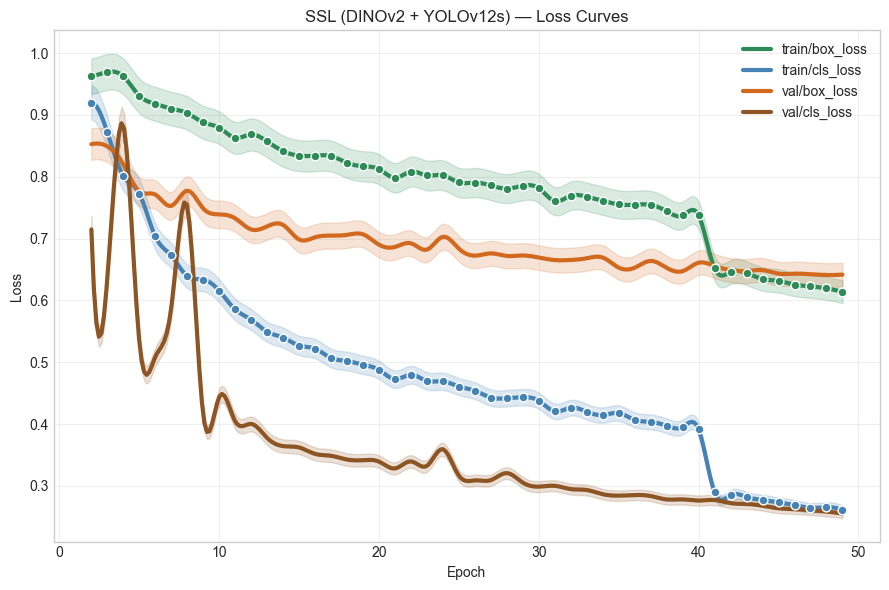

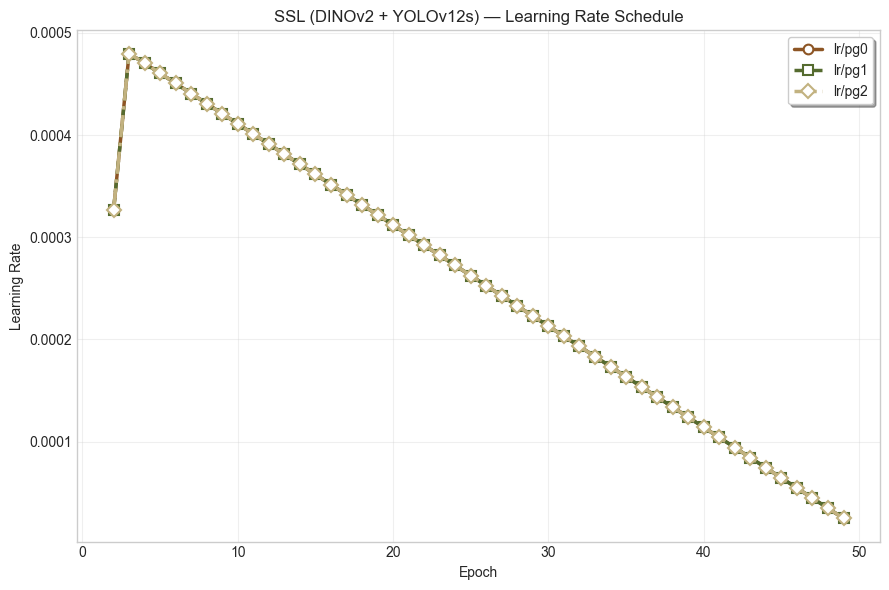

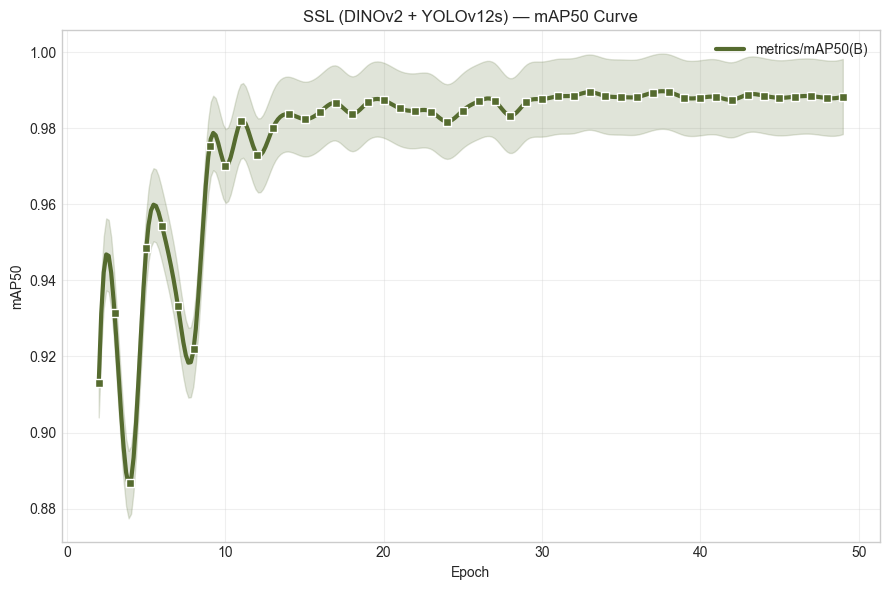

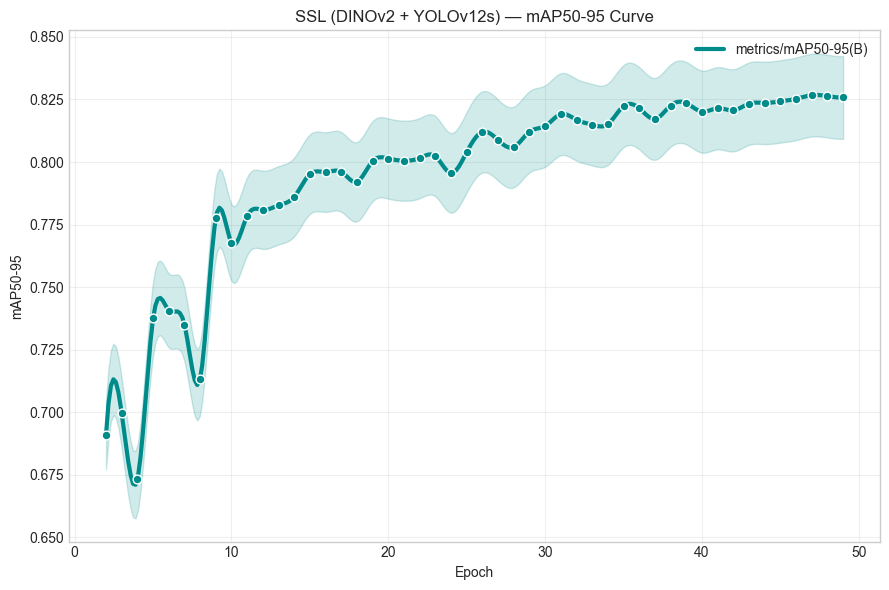

In [14]:
# ============================================================
# SSL (DINOv2 + YOLOv12s) — Ribbon Spline Curves (Except Learning Rate)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy.interpolate import make_interp_spline

# ------------------------------------------------------------
# Load CSV
# ------------------------------------------------------------
results_path = Path("/kaggle/working/Non-Seasonal-Vegetable-Detection-3/ssl_yolov12s_dinov2/results.csv")
df = pd.read_csv(results_path)

print("\nLoaded columns:", df.columns.tolist(), "\n")

# Remove first and last epoch (to avoid dips)
df_plot = df.iloc[1:-1].reset_index(drop=True)
print(f"Plotting epochs: {df_plot['epoch'].min()} → {df_plot['epoch'].max()}\n")


# ------------------------------------------------------------
# Color Palette (Consistent for all plots)
# ------------------------------------------------------------
palette = [
    "#2E8B57",  # green
    "#4682B4",  # blue
    "#D2691E",  # orange
    "#8D5524",  # brown
    "#556B2F",  # olive
    "#C2B280",  # sand
    "#008B8B",  # teal
]


# ------------------------------------------------------------
# Helper: Cubic Spline + Ribbon Fill (ONLY for Loss & mAP)
# ------------------------------------------------------------
def ribbon_spline(ax, x, y, color, label=None):
    x = np.array(x)
    y = np.array(y)

    # smooth spline
    xs = np.linspace(x.min(), x.max(), 300)
    spline = make_interp_spline(x, y, k=3)
    ys = spline(xs)

    # ribbon (soft thickness)
    ax.fill_between(xs, ys * 0.97, ys * 1.03, color=color, alpha=0.18)

    # main curve
    ax.plot(xs, ys, color=color, linewidth=3, label=label)

    return xs, ys


# ============================================================
# LOSS PLOT — Ribbon Spline Curves (Training Loss with 'o' markers)
# ============================================================
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(9, 6))

loss_keys = ["train/box_loss", "train/cls_loss", "val/box_loss", "val/cls_loss"]

for i, col in enumerate(loss_keys):
    if col not in df_plot.columns:
        continue

    color = palette[i % len(palette)]

    # Only add 'o' markers for training loss curves
    if "train" in col:
        # smooth spline
        x = np.array(df_plot["epoch"])
        y = np.array(df_plot[col])
        xs = np.linspace(x.min(), x.max(), 300)
        spline = make_interp_spline(x, y, k=3)
        ys = spline(xs)

        ax.fill_between(xs, ys * 0.97, ys * 1.03, color=color, alpha=0.18)
        ax.plot(xs, ys, color=color, linewidth=3, label=col)
        ax.scatter(x, y, color=color, marker="o", s=40, edgecolor="white", zorder=5)
    else:
        # keep previous ribbon spline without markers
        ribbon_spline(ax, df_plot["epoch"], df_plot[col], color, col)

ax.set_title("SSL (DINOv2 + YOLOv12s) — Loss Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



# ============================================================
# LEARNING RATE PLOT — DISTINCT STYLES
# ============================================================
lr_cols = [c for c in df_plot.columns if c.startswith("lr/")]

if lr_cols:
    fig, ax = plt.subplots(figsize=(9, 6))

    # Different line styles for each LR curve
    line_styles = ["-", "--", "-.", ":"]
    markers = ["o", "s", "D", "^"]

    for i, col in enumerate(lr_cols):
        color = palette[(i + 3) % len(palette)]
        style = line_styles[i % len(line_styles)]
        marker = markers[i % len(markers)]

        ax.plot(
            df_plot["epoch"],
            df_plot[col],
            color=color,
            linestyle=style,
            linewidth=2.5,
            marker=marker,
            markersize=7,
            markerfacecolor="white",
            markeredgewidth=1.5,
            label=col
        )

    ax.set_title("SSL (DINOv2 + YOLOv12s) — Learning Rate Schedule")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Learning Rate")
    ax.legend(frameon=True, shadow=True)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No learning rate columns found.")



# ============================================================
# mAP50 — Ribbon Spline (with 'o' markers)
# ============================================================
map50_col = "metrics/mAP50(B)"

if map50_col in df_plot.columns:
    fig, ax = plt.subplots(figsize=(9, 6))

    color = palette[4]

    # Smooth spline
    x = np.array(df_plot["epoch"])
    y = np.array(df_plot[map50_col])
    xs = np.linspace(x.min(), x.max(), 300)
    spline = make_interp_spline(x, y, k=3)
    ys = spline(xs)

    # Ribbon
    ax.fill_between(xs, ys * 0.99, ys * 1.01, color=color, alpha=0.18)
    ax.plot(xs, ys, color=color, linewidth=3, label=map50_col)

    # Add 'o' markers at original epochs
    ax.scatter(x, y, color=color, marker="s", s=40, edgecolor="white", zorder=5)

    ax.set_title("SSL (DINOv2 + YOLOv12s) — mAP50 Curve")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("mAP50")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("mAP50 not found.")




# ============================================================
# mAP50-95 — Ribbon Spline (with 'o' markers)
# ============================================================
map5095_col = "metrics/mAP50-95(B)"

if map5095_col in df_plot.columns:
    fig, ax = plt.subplots(figsize=(9, 6))

    color = palette[6]

    # Smooth spline
    x = np.array(df_plot["epoch"])
    y = np.array(df_plot[map5095_col])
    xs = np.linspace(x.min(), x.max(), 300)
    spline = make_interp_spline(x, y, k=3)
    ys = spline(xs)

    # Ribbon
    ax.fill_between(xs, ys * 0.98, ys * 1.02, color=color, alpha=0.18)
    ax.plot(xs, ys, color=color, linewidth=3, label=map5095_col)

    # Add 'o' markers at original epochs
    ax.scatter(x, y, color=color, marker="o", s=40, edgecolor="white", zorder=5)

    ax.set_title("SSL (DINOv2 + YOLOv12s) — mAP50-95 Curve")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("mAP50-95")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("mAP50-95 not found.")



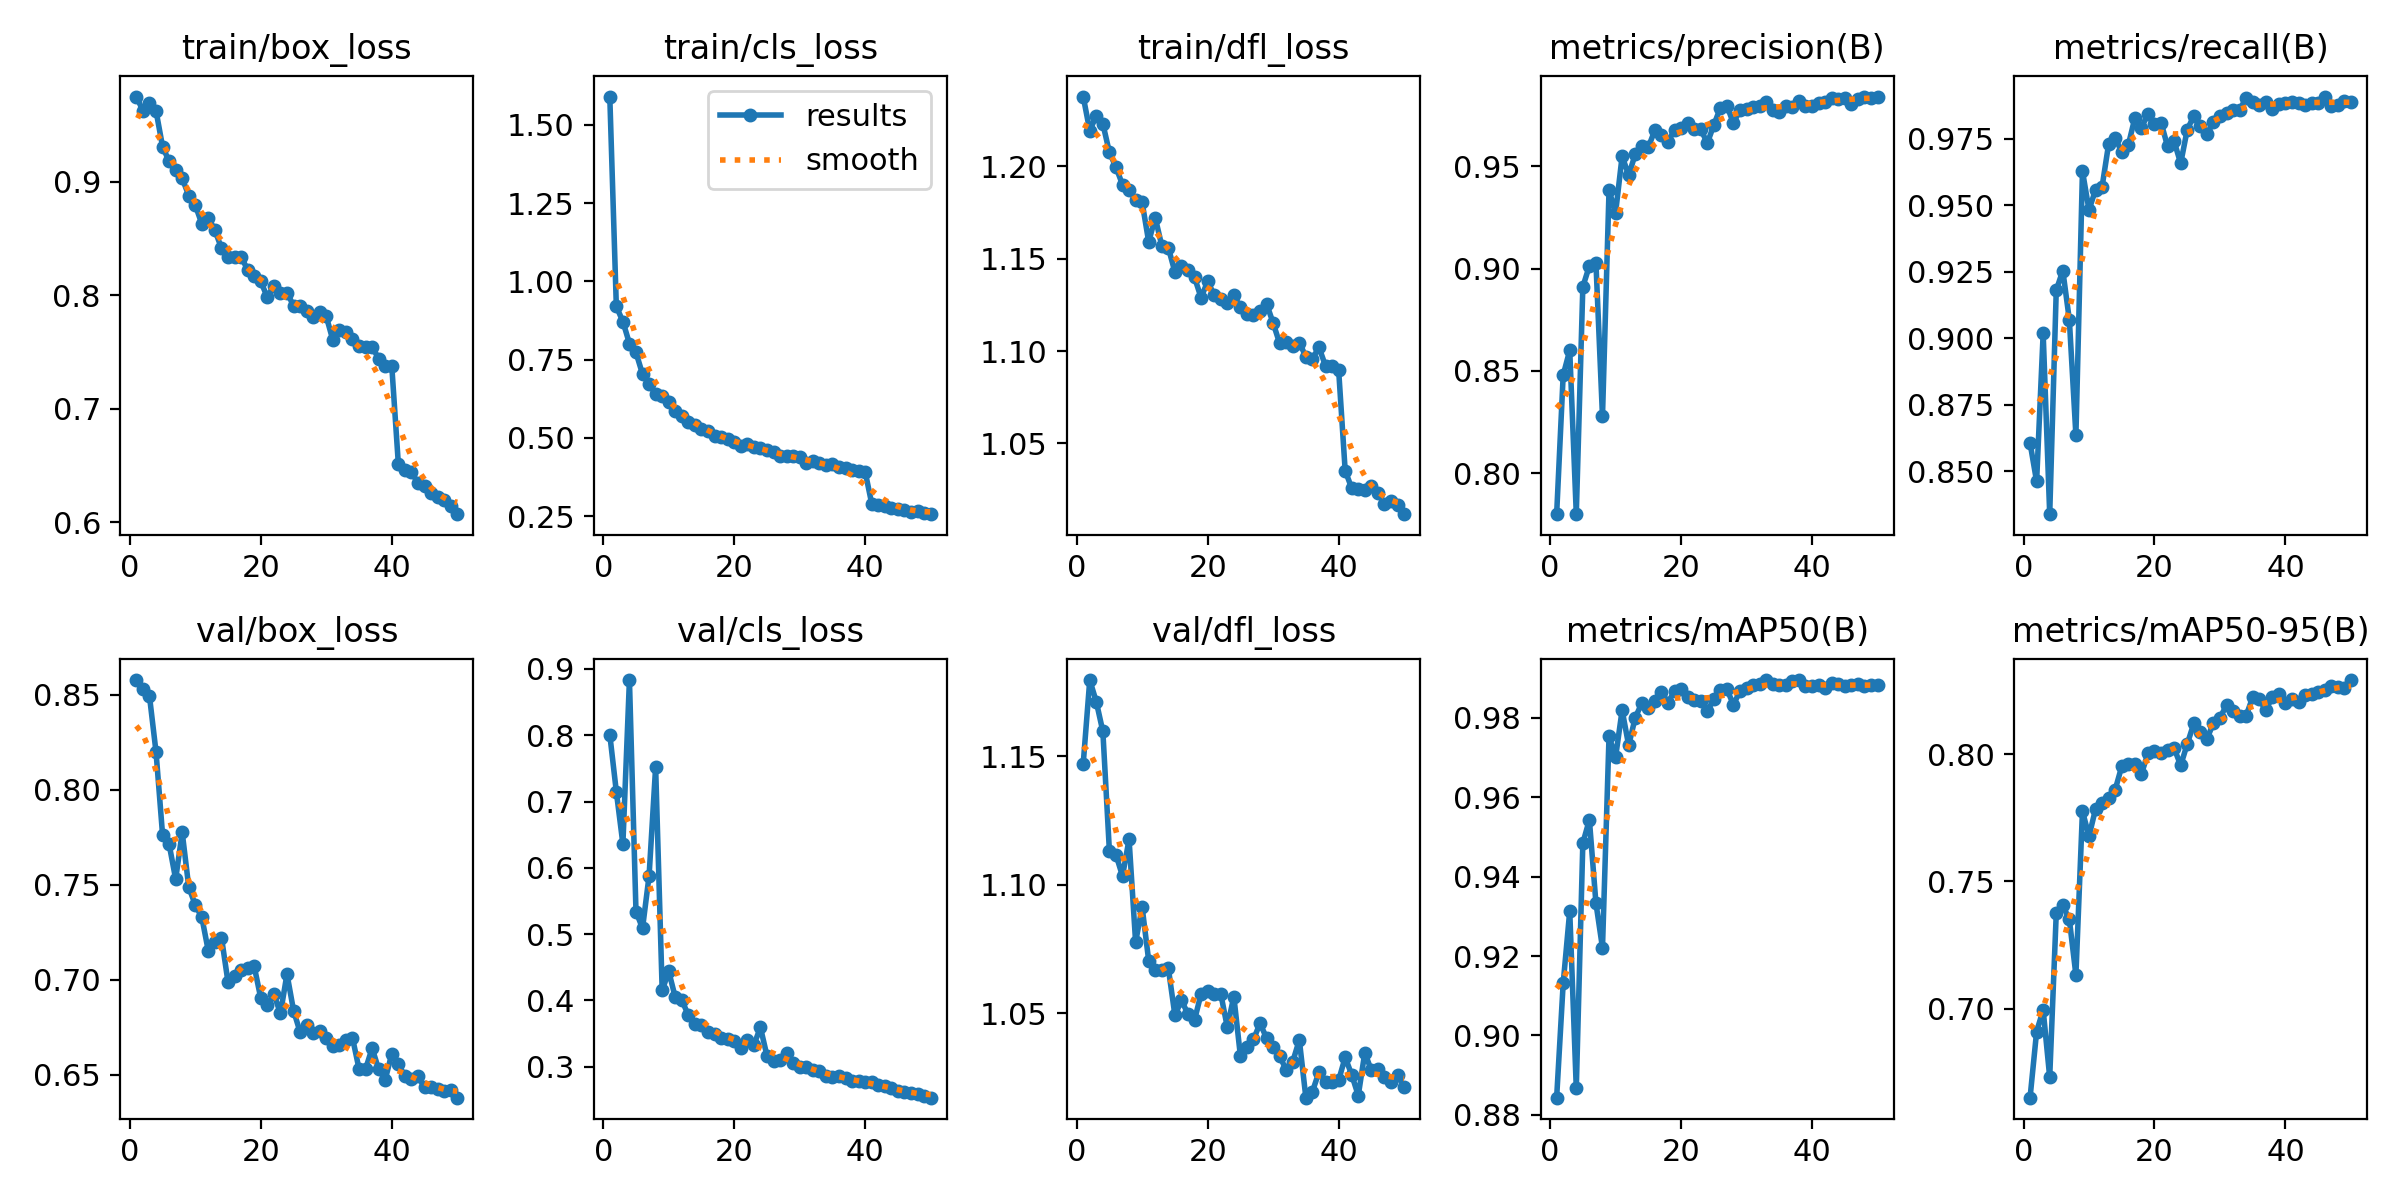

In [15]:
from PIL import Image
from IPython.display import display

results_img = WORK / "ssl_yolov12s_dinov2" / "results.png"
img = Image.open(results_img)
display(img)


## 9. Evalution

In [16]:
best_pt = Path("/kaggle/working/Non-Seasonal-Vegetable-Detection-3/ssl_yolov12s_dinov2/weights/best.pt")
 
model_det = YOLO(str(best_pt))

results = model_det.val(data=str(DATA),
                        imgsz=640,
                        batch=4,
                        device=0 if device=="cuda" else "cpu")

try:
    mp, mr, map50, map5095 = results.mean_results()
except Exception:
    mp, mr = float(results.box.mp), float(results.box.mr)
    map50, map5095 = float(results.box.map50), float(results.box.map)

print("\nValidation metrics")
print(f" Precision (mP) : {mp:.4f}")
print(f" Recall    (mR) : {mr:.4f}")
print(f" mAP@0.50      : {map50:.4f}")
print(f" mAP@0.50-0.95 : {map5095:.4f}")



Ultralytics 8.4.48 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12s summary (fused): 159 layers, 9,237,072 parameters, 0 gradients
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 989.9±406.5 MB/s, size: 29.9 KB)
val: Scanning /kaggle/working/Non-Seasonal-Vegetable-Detection-3/valid/labels.cache... 717 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 717/717 334.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 180/180 13.7it/s 13.2s


invalid value encountered in less
invalid value encountered in less


                   all        717       3615      0.984       0.99      0.988      0.829
  Bitter_Gourd_Damaged         49        222      0.991      0.981      0.994       0.86
    Bitter_Gourd_Fresh         52        161      0.974      0.994      0.994      0.873
      Cucumber_Damaged         63        254          1      0.996      0.995      0.817
        Cucumber_Fresh         64        244      0.994          1      0.995      0.838
      Eggplant_Damaged         67        246       0.98      0.988      0.992      0.876
        Eggplant_Fresh         66        227      0.958      0.943      0.977      0.855
         Lemon_Damaged         66        220      0.989      0.991      0.992      0.872
           Lemon_Fresh         65        238      0.974      0.987      0.972      0.876
         Onion_Damaged         59        228      0.958      0.991      0.962      0.616
           Onion_Fresh         59        242      0.999          1      0.995      0.686
 Pointed_Gourd_Damage

## 10. Vegetable Detection Example Images

[1] Predicting: Pointed_Gourd_Fresh_220_jpg.rf.2e30a143a523c0ea717b58fad4c8b77b.jpg
[2] Predicting: Bitter_Gourd_Damaged_143_jpg.rf.271b372417d1db54c5b051113fb2808f.jpg
[3] Predicting: Cucumber_Damaged_117_jpg.rf.4826ec7e1a482c5d9444e3014c607ff5.jpg
[4] Predicting: Eggplant_Damaged_120_jpg.rf.e08292a46d3db1319f2cd72b0018c43a.jpg


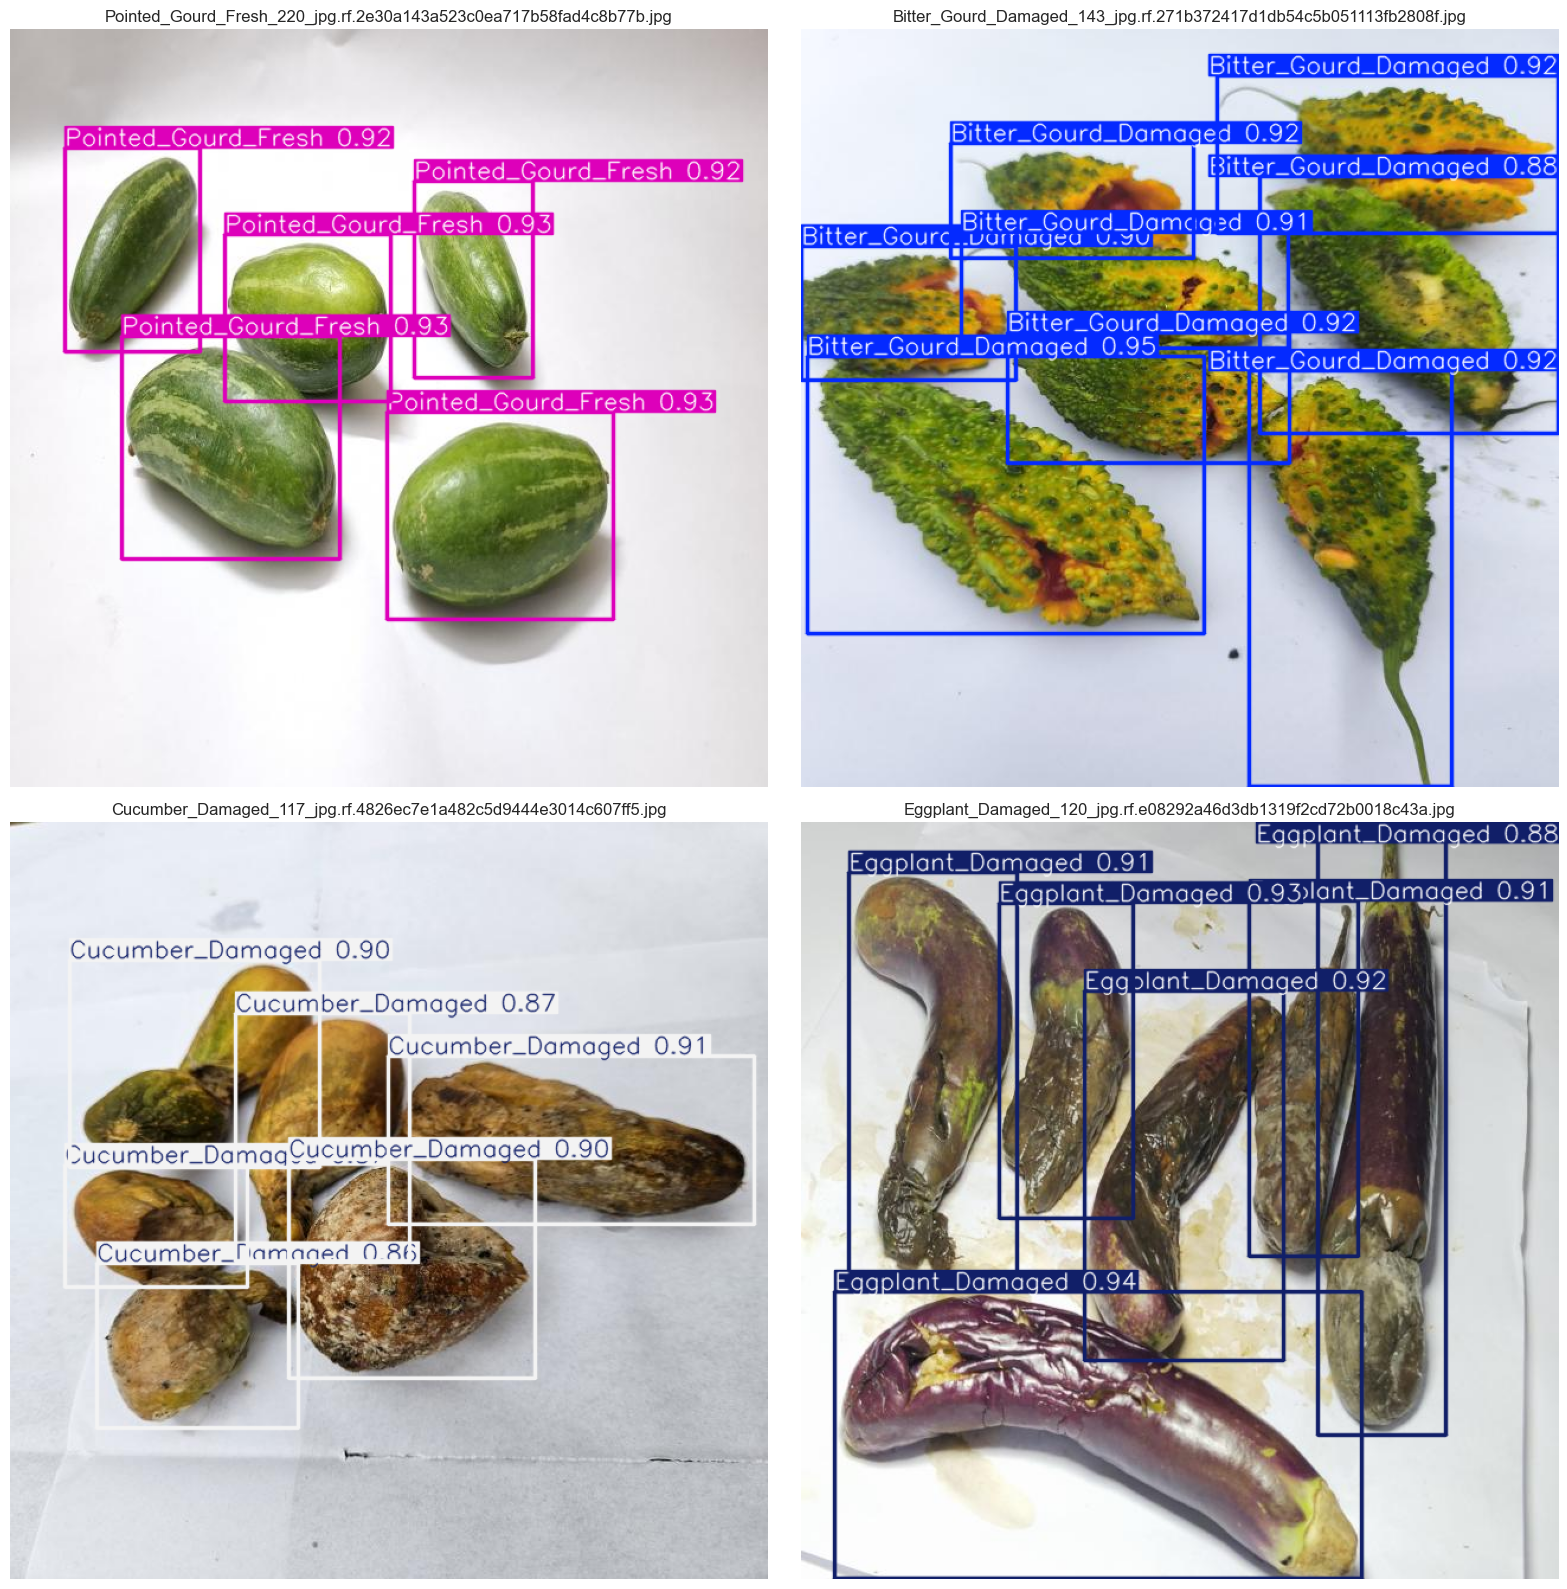

In [17]:
import random
import matplotlib.pyplot as plt
from pathlib import Path

# Ensure inline plotting for Jupyter
%matplotlib inline  

# Get all test images
test_imgs = list((WORK / "test/images").glob("*.*"))

if len(test_imgs) >= 4:
    # Pick 4 random images
    selected_imgs = random.sample(test_imgs, 4)

    plt.figure(figsize=(16, 16))
    for i, img_path in enumerate(selected_imgs, start=1):
        print(f"[{i}] Predicting: {img_path.name}")
        pred = model_det.predict(
            source=str(img_path),
            imgsz=640,
            conf=0.25,
            device=0 if device == "cuda" else "cpu",
            verbose=False
        )[0]

        plotted_img = pred.plot()[:, :, ::-1] if pred else plt.imread(img_path)

        plt.subplot(2, 2, i)
        plt.imshow(plotted_img)
        plt.axis("off")
        plt.title(img_path.name)

    plt.tight_layout()
    plt.show()
else:
    print(f"Not enough test images found (found {len(test_imgs)}, need at least 4).")



 Evaluating …
Ultralytics 8.4.48 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12s summary (fused): 159 layers, 9,237,072 parameters, 0 gradients
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 913.7±363.9 MB/s, size: 38.1 KB)
val: Scanning /kaggle/working/Non-Seasonal-Vegetable-Detection-3/valid/labels.cache... 717 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 717/717 273.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 180/180 13.6it/s 13.2s


invalid value encountered in less
invalid value encountered in less


                   all        717       3615      0.984       0.99      0.988      0.829
  Bitter_Gourd_Damaged         49        222      0.991      0.981      0.994       0.86
    Bitter_Gourd_Fresh         52        161      0.974      0.994      0.994      0.873
      Cucumber_Damaged         63        254          1      0.996      0.995      0.817
        Cucumber_Fresh         64        244      0.994          1      0.995      0.838
      Eggplant_Damaged         67        246       0.98      0.988      0.992      0.876
        Eggplant_Fresh         66        227      0.958      0.943      0.977      0.855
         Lemon_Damaged         66        220      0.989      0.991      0.992      0.872
           Lemon_Fresh         65        238      0.974      0.987      0.972      0.876
         Onion_Damaged         59        228      0.958      0.991      0.962      0.616
           Onion_Fresh         59        242      0.999          1      0.995      0.686
 Pointed_Gourd_Damage

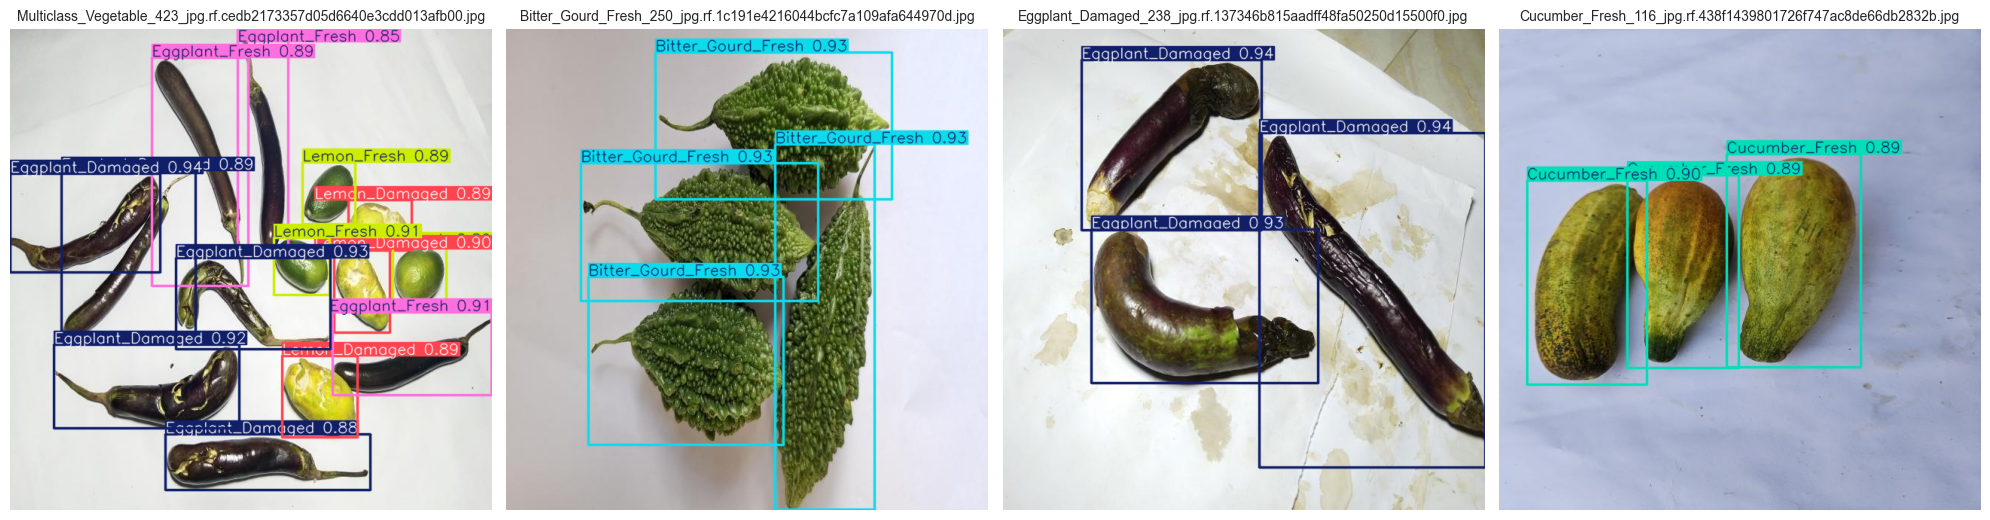

In [18]:

print("\n Evaluating …")
best_pt = WORK / "ssl_yolov12s_dinov2"/"weights"/"best.pt"
model   = YOLO(str(best_pt))
results = model.val(data=str("/kaggle/working/Non-Seasonal-Vegetable-Detection-3/data.yaml"), imgsz=640, batch=4, device=0 if device=="cuda" else None)

try:
    mp,mr,map50,map5095 = results.mean_results()
    print("\nValidation metrics")
    print(f"Precision (mP)   : {mp:.4f}")
    print(f"Recall (mR)      : {mr:.4f}")
    print(f"mAP@0.50         : {map50:.4f}")
    print(f"mAP@0.50:0.95    : {map5095:.4f}")
except Exception:
    print("Ultralytics API changed; raw results follows:")
    print(results)

import random

# pick from test or valid images
cands = list((WORK/"test"/"images").glob("*.*")) or list((WORK/"valid"/"images").glob("*.*"))

if cands:
    imgs = random.sample(cands, min(4, len(cands)))  # pick up to 4 random images
    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    axes = axes.flatten()

    for ax, img_path in zip(axes, imgs):
        print("Visualising:", img_path.name)
        pred = model.predict(
            source=str(img_path),
            imgsz=640,
            conf=0.25,
            device=0 if device == "cuda" else None,
            verbose=False
        )[0]
        ax.imshow(pred.plot()[:,:,::-1])
        ax.axis("off")
        ax.set_title(img_path.name, fontsize=10)

    # hide unused axes if <4 images
    for ax in axes[len(imgs):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

else:
    print("No images found for visualization.")

